<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/ml_python.png' width=600/></center>

<img src = "https://github.com/Jangrae/img/blob/master/iris2.png?raw=true" width=800 align="left"/>

# 실습 내용

- Iris 데이터로 모델링합니다.
- Logistic Regression 알고리즘으로 모델링합니다.

# 1.환경 준비

- 기본 라이브러리와 대상 데이터를 가져와 이후 과정을 준비합니다.

In [5]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [6]:
# 데이터 읽어오기
path = 'https://raw.githubusercontent.com/jangrae/csv/master/iris.csv'
data = pd.read_csv(path)

# 2.데이터 이해

- 분석할 데이터를 충분히 이해할 수 있도록 다양한 탐색 과정을 수행합니다.

In [9]:
# 상위 몇 개 행 확인
data.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**데이터 설명**

- COLLEGE: 대학 졸업여부
- INCOME: 연수입
- OVERAGE: 월평균 초과사용 시간(분)
- LEFTOVER: 월평균 잔여시간비율(%)
- HOUSE: 집값
- HANDSET_PRICE: 스마트폰 가격
- OVER_15MINS_CALLS_PER_MONTH: 월평균 장기통화(15분이상) 횟수
- AVERAGE_CALL_DURATION: 평균 통화 시간
- REPORTED_SATISFACTION: 만족도 설문조사 결과
- REPORTED_USAGE_LEVEL: 사용도 자가진단 결과
- CONSIDERING_CHANGE_OF_PLAN: 향후 변경계획 설문조사 결과
- CHURN: 이탈(번호이동) 여부 (Target 변수)

In [11]:
# 변수 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [13]:
# 기술통계 확인
data.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
# target 값 개수 확인
data['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [18]:
# 상관관계 확인
data.corr(numeric_only=True)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.000000,-0.117570,0.871754,0.817941
Sepal.Width,-0.117570,1.000000,-0.428440,-0.366126
Petal.Length,0.871754,-0.428440,1.000000,0.962865
Petal.Width,0.817941,-0.366126,0.962865,1.000000


# 3.데이터 준비

- 전처리 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비합니다.

**1) x, y 분리**

In [24]:
# Target 설정
target = 'Species'

# 데이터 분리
x = data.drop(columns = target)
y = data.loc[:, target]


**2) 학습용, 평가용 데이터 분리**

In [32]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y, random_state = 1)

# 4.모델링

- 본격적으로 모델을 선언하고 학습하고 평가하는 과정을 진행합니다.

In [35]:
# 1단계: 불러오기
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, classification_report

In [37]:
# 2단계: 선언하기
model = LogisticRegression()

In [39]:
# 3단계: 학습하기
model.fit(x_train, y_train)

LogisticRegression()

In [41]:
# 4단계: 예측하기
y_pred = model.predict(x_test)

In [43]:
# 5단계: 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



# 5. 모델 살펴보기

* **소프트맥스 수식**
$$ \large P(y=k|x)=\frac{e^{z_k}}{\sum^K_{j=1}e^{z_j}} $$

In [50]:
# 회귀계수 확인
print(list(x))
print(model.coef_)
print(model.intercept_)

# 변수가 4개인데 왜 가중치가 12개(세줄)이지?
# 세토사, 버지칼라, 버지니카 세가지를 예측해야한다.

# 세토사를 예측했을 때 사용했던 가중치(첫번째 줄)
# 버지칼라를 " (두번째 줄)
# 버지니카를 " (세번째 줄)

['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']
[[-0.4808825   0.77870161 -2.29149703 -0.92166337]
 [ 0.15174961 -0.21708714 -0.07817951 -0.69361032]
 [ 0.32913289 -0.56161448  2.36967653  1.61527369]]
[  9.79209539   3.11181184 -12.90390724]


In [54]:
# 선형 판별식(z) 얻기
z = model.decision_function(x_test)
print(z[:5])

[[-5.0357003   1.29709011  3.7386102 ]
 [ 5.9680559   2.67427064 -8.64232653]
 [ 6.74302654  2.7542294  -9.49725593]
 [-2.49603916  1.78172178  0.71431738]
 [-2.41853989  2.1470536   0.27148629]]


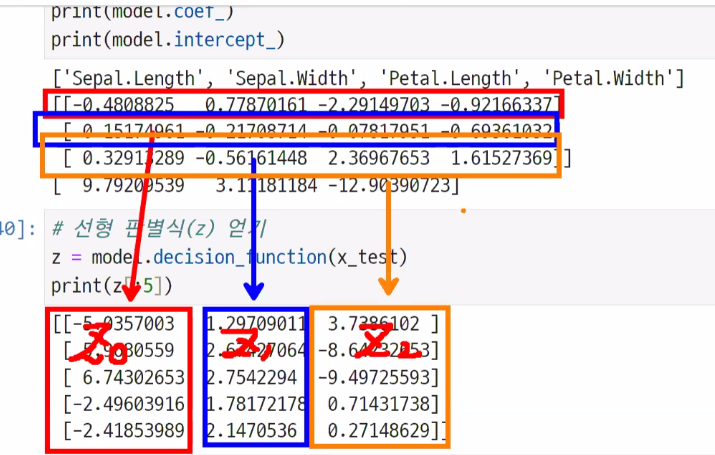

In [62]:
# softmax 함수 사용
# 직접 계산한 확률 값
from scipy.special import softmax
print(softmax(z, axis=1)[:5].round(2))

[[0.   0.08 0.92]
 [0.96 0.04 0.  ]
 [0.98 0.02 0.  ]
 [0.01 0.74 0.25]
 [0.01 0.86 0.13]]


In [64]:
print(y_pred[:5])

['virginica' 'setosa' 'setosa' 'versicolor' 'versicolor']


In [66]:
# model.predict_proba로 계산한 확률 값
p = model.predict_proba(x_test)
print(p[:5].round(2))

[[0.   0.08 0.92]
 [0.96 0.04 0.  ]
 [0.98 0.02 0.  ]
 [0.01 0.74 0.25]
 [0.01 0.86 0.13]]
